# Training of the models
In this notebook, you can choose your own data and model parameters, train the model, and make a plot for the joint contours of posteriors

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import matplotlib.pyplot as plt
import pydelfi.priors as priors
import pydelfi.ndes as ndes
import pydelfi.delfi as delfi
import tensorflow as tf
import pickle
from getdist import plots, MCSamples
import getdist
%matplotlib inline

/home/zxs/miniconda3/envs/21cmfast2/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/home/zxs/miniconda3/envs/21cmfast2/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/home/zxs/miniconda3/envs/21cmfast2/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/home/zxs/miniconda3/envs/21cmfast2/lib/pyt

/home/zxs/miniconda3/envs/21cmfast2/lib/python3.6/site-packages/tensorboard/compat/tensorflow_stub/dtypes.py:541: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/home/zxs/miniconda3/envs/21cmfast2/lib/python3.6/site-packages/tensorboard/compat/tensorflow_stub/dtypes.py:542: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/home/zxs/miniconda3/envs/21cmfast2/lib/python3.6/site-packages/tensorboard/compat/tensorflow_stub/dtypes.py:543: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/home/zxs/miniconda3/e

In [ ]:
#define the parameter prior 
lower = np.array([2,8,0.1,0.2])
upper = np.array([20,10,1,2])

prior = priors.Uniform(lower, upper)

#testing data
theta_fiducials = np.load('/scratch/zxs/scripts/SKA_test/powerspectrum_noisy/parameters_mock.npy').reshape(1,4)

compressed_datas = np.load('/scratch/zxs/scripts/SKA_test/powerspectrum_noisy/powerspectrum_mock.npy').reshape(1,660)
print(theta_fiducials.shape)

# Parameters
n_samples = 1
vector_length = 55
n_vectors = 12
n_segments = 6

# Reshape to separate the 12 vectors
data_reshaped = compressed_datas.reshape(n_samples, n_vectors, vector_length)

# Calculate segment boundaries
segment_edges = np.linspace(0, vector_length, n_segments + 1).astype(int)

# Average each segment for each vector
averaged_data = np.zeros((n_samples, n_vectors, n_segments))
for i in range(n_segments):
    start_idx = segment_edges[i]
    end_idx = segment_edges[i + 1]
    averaged_data[:, :, i] = data_reshaped[:, :, start_idx:end_idx].mean(axis=2)

# Flatten back to 2D: shape will be (1, 72) = (1, 12*6)
compressed_datas = averaged_data.reshape(n_samples, -1)

print(f"Reshaped: {data_reshaped.shape}")
print(f"Segment edges: {segment_edges}")
print(f"Averaged shape: {averaged_data.shape}")
print(f"Flattened averaged shape: {compressed_datas.shape}")

#training data
sim_params = np.load('/scratch/zxs/scripts/SKA_test/powerspectrum_noisy/parameters_train.npy')[:,:]
sim_compressed_data=np.load('/scratch/zxs/scripts/SKA_test/powerspectrum_noisy/powerspectrum_train.npy')[:,:]

# Parameters
n_samples = 995
vector_length = 55
n_vectors = 12
n_segments = 6

# Reshape to separate the 12 vectors
data_reshaped = sim_compressed_data.reshape(n_samples, n_vectors, vector_length)

# Calculate segment boundaries
segment_edges = np.linspace(0, vector_length, n_segments + 1).astype(int)

# Average each segment for each vector
averaged_data = np.zeros((n_samples, n_vectors, n_segments))
for i in range(n_segments):
    start_idx = segment_edges[i]
    end_idx = segment_edges[i + 1]
    averaged_data[:, :, i] = data_reshaped[:, :, start_idx:end_idx].mean(axis=2)

# Flatten back to 2D: shape will be (900, 72) = (900, 12*6)
sim_compressed_data = averaged_data.reshape(n_samples, -1)

print(f"Reshaped: {data_reshaped.shape}")
print(f"Segment edges: {segment_edges}")
print(f"Averaged shape: {averaged_data.shape}")
print(f"Flattened averaged shape: {sim_compressed_data.shape}")

#dimension of the data summary
nd = compressed_datas.shape[1]

#0 for the fiducial model
theta_fiducial = theta_fiducials[0]
compressed_data = compressed_datas[0]

#directory of the results
diri = "data/diagnostics/trained_sirius_ps_noisy_subsample2_avepoints/"

(1, 4)
Reshaped: (1, 12, 55)
Segment edges: [ 0  9 18 27 36 45 55]
Averaged shape: (1, 12, 6)
Flattened averaged shape: (1, 72)
Reshaped: (995, 12, 55)
Segment edges: [ 0  9 18 27 36 45 55]
Averaged shape: (995, 12, 6)
Flattened averaged shape: (995, 72)


## prepare the data

## Choose the model

In [4]:
NDEs = [ndes.ConditionalMaskedAutoregressiveFlow(n_parameters=4, n_data=nd, n_hiddens=[50,50], n_mades=5, act_fun=tf.tanh, index=0),
            ndes.ConditionalMaskedAutoregressiveFlow(n_parameters=4, n_data=nd, n_hiddens=[50,50], n_mades=5, act_fun=tf.tanh, index=1),
            ndes.ConditionalMaskedAutoregressiveFlow(n_parameters=4, n_data=nd, n_hiddens=[50,50], n_mades=5, act_fun=tf.tanh, index=2),
            ndes.ConditionalMaskedAutoregressiveFlow(n_parameters=4, n_data=nd, n_hiddens=[50,50], n_mades=5, act_fun=tf.tanh, index=3)]





Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


## initialization

In [5]:
DelfiEnsemble = delfi.Delfi(compressed_data, prior, NDEs, 
                            Finv = None, 
                            n_procs = 1,
                            theta_fiducial = theta_fiducial, 
                            param_limits = [lower, upper],
                            param_names = ['zeta_uv', 'log_10 M_turn', 'zeta_x', 'zeta_alpha'], 
                            results_dir = diri,
                            progress_bar = False,
                            input_normalization=None)

## data loading and training 

In [6]:
DelfiEnsemble.load_simulations(sim_compressed_data, sim_params)
DelfiEnsemble.train_ndes()


Instructions for updating:
Use standard file APIs to check for files with this prefix.
INFO:tensorflow:Restoring parameters from data/diagnostics/trained_sirius_ps_noisy_subsample2_avepoints/graph_checkpoint
INFO:tensorflow:Restoring parameters from data/diagnostics/trained_sirius_ps_noisy_subsample2_avepoints/graph_checkpoint
INFO:tensorflow:Restoring parameters from data/diagnostics/trained_sirius_ps_noisy_subsample2_avepoints/graph_checkpoint
INFO:tensorflow:Restoring parameters from data/diagnostics/trained_sirius_ps_noisy_subsample2_avepoints/graph_checkpoint


## sample and save the posteriors

In [7]:
posterior_samples = DelfiEnsemble.emcee_sample(burn_in_chain=500, main_chain=500)
with open('data/posterior_samples/po_mock_sirius_ps_noisy_subsample2_avepoints.pkl', 'wb') as f:
    pickle.dump(posterior_samples,f)

SIRIUS-st shape: (24984, 4)
SIRIUS-st unique shape: (24984, 4)
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


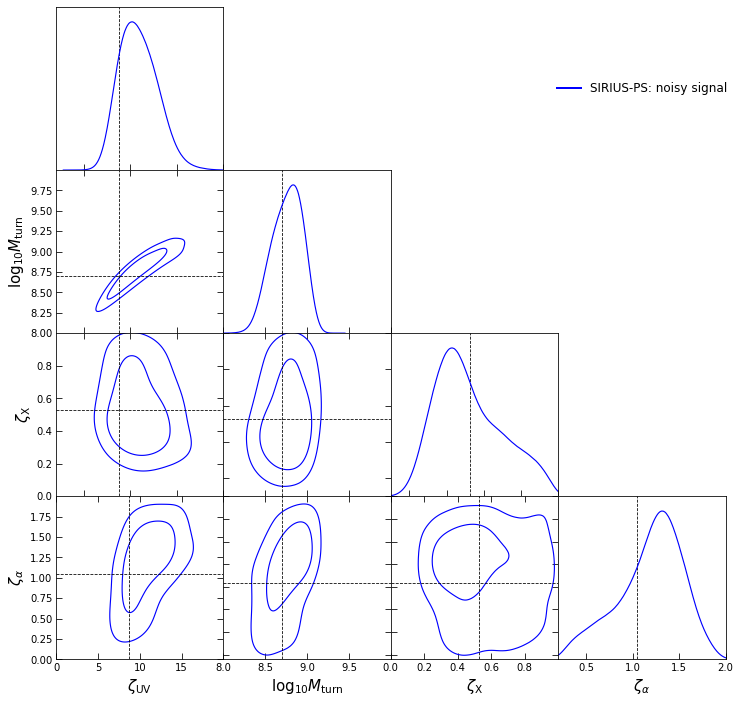

<Figure size 288x216 with 0 Axes>

In [ ]:
%matplotlib inline
from getdist import plots, MCSamples
import getdist
import matplotlib.pyplot as plt
import pickle
import numpy as np

param_names = ['zeta_uv', 'log_10M_turn', 'zeta_x', 'zeta_alpha']
lower = np.array([2, 8, 0.1, 0.2])
upper = np.array([20, 10, 1, 2])

def plots_all(d_all, colorl, colorx, label):
    # Create 1D samples for each parameter
    samples_1d = [MCSamples(samples=[d_all[:,i]], names=[param_names[i]], 
                           labels=[param_names[i]], label=label) 
                  for i in range(4)]
    
    # Add 1D distributions to diagonal
    for i in range(4):
        g.add_1d(samples_1d[i], param_names[i], ax=ax[i,i], color=colorl)
    
    # Create 2D samples and add contour plots for lower triangle
    sample_all = MCSamples(samples=d_all, names=param_names, labels=param_names, label=label)
    for i in range(4):
        for j in range(i):
            g.add_2d_contours(sample_all, param_names[j], param_names[i], 
                            ax=ax[i,j], color=colorl, filled=False, 
                            contour_levels=[0.32, 0.05])

for num in range(1):
    fig, ax = plt.subplots(figsize=(12,12), nrows=4, ncols=4, 
                          gridspec_kw={'hspace': 0, 'wspace': 0})
    
    # Set up each subplot
    # Row 0 (zeta_uv)
    ax[0,0].set_yticks([])
    ax[0,0].set_xlim(lower[0], upper[0])
    ax[0,0].set_ylim(0, 1.1)
    ax[0,0].axvline(theta_fiducial[0], linestyle='--', c='k', lw=.8)
    ax[0,0].tick_params(axis='x', top=False, direction="in", length=6, labelbottom=False)
    
    for j in range(1, 4):
        ax[0,j].set(frame_on=False)
        ax[0,j].set_yticks([])
        ax[0,j].set_xticks([])
    
    # Row 1 (log_10 M_turn)
    ax[1,0].set_xlim(lower[0], upper[0])
    ax[1,0].set_ylim(lower[1], upper[1])
    ax[1,0].tick_params(axis='both', top=True, right=True, direction="in", length=6, labelbottom=False)
    ax[1,0].axvline(theta_fiducial[0], linestyle='--', c='k', lw=.8)
    ax[1,0].axhline(theta_fiducial[1], linestyle='--', c='k', lw=.8)
    ax[1,0].set_ylabel("$\\log_{10} M_{\\rm turn}$", fontsize=15)
    yticks = ax[1,0].get_yticks()
    ax[1,0].set_yticks(yticks[:-1])
    
    ax[1,1].set_yticks([])
    ax[1,1].set_xlim(lower[1], upper[1])
    ax[1,1].set_ylim(0, 1.1)
    ax[1,1].axvline(theta_fiducial[1], linestyle='--', c='k', lw=.8)
    ax[1,1].tick_params(axis='x', top=False, direction="in", length=6, labelbottom=False)
    
    for j in range(2, 4):
        ax[1,j].set(frame_on=False)
        ax[1,j].set_yticks([])
        ax[1,j].set_xticks([])
    
    # Row 2 (zeta_x)
    ax[2,0].set_xlim(lower[0], upper[0])
    ax[2,0].set_ylim(lower[2], upper[2])
    ax[2,0].tick_params(axis='both', top=True, right=True, direction="in", length=6, labelbottom=False)
    ax[2,0].axvline(theta_fiducial[0], linestyle='--', c='k', lw=.8)
    ax[2,0].axhline(theta_fiducial[2], linestyle='--', c='k', lw=.8)
    ax[2,0].set_ylabel("$\\zeta_{\\rm X}$", fontsize=15)
    yticks = ax[2,0].get_yticks()
    ax[2,0].set_yticks(yticks[:-1])
    
    ax[2,1].set_xlim(lower[1], upper[1])
    ax[2,1].set_ylim(lower[2], upper[2])
    ax[2,1].tick_params(axis='both', top=True, right=True, direction="in", length=6, labelbottom=False, labelleft=False)
    ax[2,1].axvline(theta_fiducial[1], linestyle='--', c='k', lw=.8)
    ax[2,1].axhline(theta_fiducial[2], linestyle='--', c='k', lw=.8)
    
    ax[2,2].set_yticks([])
    ax[2,2].set_xlim(lower[2], upper[2])
    ax[2,2].set_ylim(0, 1.1)
    ax[2,2].axvline(theta_fiducial[2], linestyle='--', c='k', lw=.8)
    ax[2,2].tick_params(axis='x', top=False, direction="in", length=6, labelbottom=False)
    
    ax[2,3].set(frame_on=False)
    ax[2,3].set_yticks([])
    ax[2,3].set_xticks([])
    
    # Row 3 (zeta_alpha)
    ax[3,0].set_xlim(lower[0], upper[0])
    ax[3,0].set_ylim(lower[3], upper[3])
    ax[3,0].tick_params(axis='both', top=True, right=True, direction="in", length=6)
    ax[3,0].axvline(theta_fiducial[0], linestyle='--', c='k', lw=.8)
    ax[3,0].axhline(theta_fiducial[3], linestyle='--', c='k', lw=.8)
    ax[3,0].set_xlabel("$\\zeta_{\\rm UV}$", fontsize=15)
    ax[3,0].set_ylabel("$\\zeta_{\\alpha}$", fontsize=15)
    xticks = ax[3,0].get_xticks()
    ax[3,0].set_xticks(xticks[:-1])
    yticks = ax[3,0].get_yticks()
    ax[3,0].set_yticks(yticks[:-1])
    
    ax[3,1].set_xlim(lower[1], upper[1])
    ax[3,1].set_ylim(lower[3], upper[3])
    ax[3,1].tick_params(axis='both', top=True, right=True, direction="in", length=6, labelleft=False)
    ax[3,1].axvline(theta_fiducial[1], linestyle='--', c='k', lw=.8)
    ax[3,1].axhline(theta_fiducial[3], linestyle='--', c='k', lw=.8)
    ax[3,1].set_xlabel("$\\log_{10} M_{\\rm turn}$", fontsize=15)
    xticks = ax[3,1].get_xticks()
    ax[3,1].set_xticks(xticks[:-1])
    
    ax[3,2].set_xlim(lower[2], upper[2])
    ax[3,2].set_ylim(lower[3], upper[3])
    ax[3,2].tick_params(axis='both', top=True, right=True, direction="in", length=6, labelleft=False)
    ax[3,2].axvline(theta_fiducial[2], linestyle='--', c='k', lw=.8)
    ax[3,2].axhline(theta_fiducial[3], linestyle='--', c='k', lw=.8)
    ax[3,2].set_xlabel("$\\zeta_{\\rm X}$", fontsize=15)
    xticks = ax[3,2].get_xticks()
    ax[3,2].set_xticks(xticks[:-1])
    
    ax[3,3].set_yticks([])
    ax[3,3].set_xlim(lower[3], upper[3])
    ax[3,3].set_ylim(0, 1.1)
    ax[3,3].axvline(theta_fiducial[3], linestyle='--', c='k', lw=.8)
    ax[3,3].tick_params(axis='x', top=False, direction="in", length=6)
    ax[3,3].set_xlabel("$\\zeta_{\\alpha}$", fontsize=15)
    
    g = plots.getSinglePlotter(width_inch=4)
    
    # Load and plot 
    f_ps = open("data/posterior_samples/po_mock_sirius_ps_noisy_subsample2_avepoints.pkl", 'rb')
    d_ps = pickle.load(f_ps)
    f_ps.close()
    print("SIRIUS-PS shape:", d_ps[0].shape)
    sample_ps = np.unique(d_ps[0], axis=0, return_counts=False)
    print("SIRIUS-PS unique shape:", sample_ps.shape)
    plots_all(sample_ps, 'blue', 'blue', 'SIRIUS-PS')
    
    # Add legend
    ax[0,0].legend(loc='upper right', fontsize=12, frameon=False)

    # Add legend to upper right empty subplot
    from matplotlib.lines import Line2D
    legend_elements = [
                      Line2D([0], [0], color='blue', lw=2, label='SIRIUS-PS: noisy signal')]
    ax[0,3].legend(handles=legend_elements, loc='center', fontsize=12, frameon=False)
    
    plt.show()